# Práctica 1 — Modelación de datos biológicos
## Obtención de modelos fenomenológicos con regresión

En este notebook vamos a resolver 4 ejercicios paso a paso, usando una idea simple:
**dejar que los datos nos digan qué modelo tiene más sentido**.

---

### Objetivo
Encontrar, para cada conjunto de datos experimentales, un modelo que describa bien
la relación entre variables y que cumpla el criterio de error pedido en el enunciado:

$$(1-R^2)\times100\%$$

### Forma de trabajo (la misma en todos los ejercicios)
1. Ver los datos en una gráfica de dispersión.
2. Probar modelos de menor a mayor complejidad.
3. Quedarnos con el modelo más simple que cumpla el error solicitado.
4. Interpretar $R^2$ (y $r$ cuando aplica) en lenguaje claro.
5. Hacer las predicciones pedidas y avisar cuando haya extrapolación.


## 0. Librerías utilizadas

Usaremos solo herramientas estándar para análisis y modelado:

- **numpy**: operaciones numéricas y arreglos.
- **pandas**: lectura y manejo de los `.csv`.
- **matplotlib.pyplot**: gráficas.
- **LinearRegression** (`sklearn`): regresión lineal y base de la polinomial.
- **PolynomialFeatures** (`sklearn`): creación de términos $x^2, x^3, ...$.
- **r2_score** (`sklearn`): cálculo de $R^2$.
- **curve_fit** (`scipy`): ajuste no lineal (por ejemplo, exponencial).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit

# Forma general para las gráficas
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [ ]:
def calcular_r2_r(y_real, y_pred):
    r2 = r2_score(y_real, y_pred)
    r = np.corrcoef(y_real, y_pred)[0, 1]
    return r2, r


def resumen_modelo(nombre, y_real, y_pred):
    r2, r = calcular_r2_r(y_real, y_pred)
    error_pct = 100 * (1 - r2)
    print(f"{nombre:<25} R2={r2:.4f}   error=({1-r2:.4f})*100%={error_pct:.2f}%   r={r:.4f}")
    return r2, r

---
# Punto 1 — Índice de glucosa vs. estadía hospitalaria

Queremos modelar cómo cambia la **estadía hospitalaria** según el
**índice de glucosa** usado en el diagnóstico de meningitis.

✅ Criterio exigido: $(1 - R^2)\times100\% < 15\%$


In [ ]:
df_glucosa = pd.read_csv("ej1_glucosa.csv")
df_glucosa.head()

,indice_glucosa,estadia_hospitalaria
0,0.12,20
1,0.16,16
2,0.34,14
3,0.36,12
4,0.31,13


In [ ]:
indice_glucosa = df_glucosa["indice_glucosa"].to_numpy()
estadia_hospitalaria = df_glucosa["estadia_hospitalaria"].to_numpy()

print(f"Número de observaciones: {len(indice_glucosa)}")
print(f"Rango de glucosa: [{indice_glucosa.min()}, {indice_glucosa.max()}]")
print(f"Rango de estadía: [{estadia_hospitalaria.min()}, {estadia_hospitalaria.max()}]")

Numero de observaciones: 18
Rango de glucosa: [0.12, 0.71]
Rango de estadia: [6, 20]


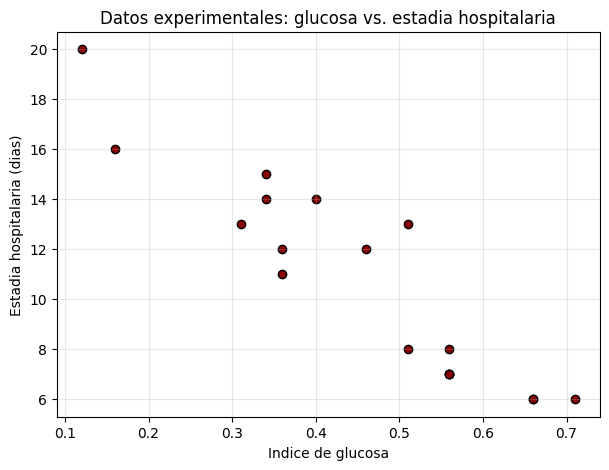

In [ ]:
fig, ax = plt.subplots()
ax.scatter(indice_glucosa, estadia_hospitalaria, color="darkred")
ax.set_xlabel("Indice de glucosa")
ax.set_ylabel("Estadia hospitalaria (dias)")
ax.set_title("Datos experimentales: glucosa vs. estadia hospitalaria")
plt.show()

### Qué se ve en la gráfica

La relación es decreciente y se va aplanando. Eso sugiere un comportamiento exponencial con saturación.


## 1.2 Probar modelos candidatos

Empezamos por modelos simples y subimos complejidad solo si hace falta para cumplir el criterio.


In [6]:
# --- Modelo 1: Regresion lineal simple ---
# sklearn exige que x sea una matriz 2D (n_observaciones, n_variables)
indice_glucosa_2d = indice_glucosa.reshape(-1, 1)

modelo_lineal_glucosa = LinearRegression()
modelo_lineal_glucosa.fit(indice_glucosa_2d, estadia_hospitalaria)
estadia_predicha_lineal = modelo_lineal_glucosa.predict(indice_glucosa_2d)

resumen_modelo("Lineal", estadia_hospitalaria, estadia_predicha_lineal)

Lineal                    R2=0.8605   error=(0.1395)*100%=13.95%   r=0.9276


(0.8604689568803032, np.float64(0.9276146596945862))

In [7]:
# --- Modelo 2: Regresion polinomial grado 2 ---
transformador_polinomial_glucosa = PolynomialFeatures(degree=2)
indice_glucosa_polinomico = transformador_polinomial_glucosa.fit_transform(indice_glucosa_2d)

modelo_polinomial_glucosa = LinearRegression()
modelo_polinomial_glucosa.fit(indice_glucosa_polinomico, estadia_hospitalaria)
estadia_predicha_polinomial = modelo_polinomial_glucosa.predict(indice_glucosa_polinomico)

resumen_modelo("Polinomial grado 2", estadia_hospitalaria, estadia_predicha_polinomial)

Polinomial grado 2        R2=0.8608   error=(0.1392)*100%=13.92%   r=0.9278


(0.8608465793338899, np.float64(0.9278181822608833))

In [8]:
# --- Modelo 3: Exponencial decreciente simple  y = a*exp(-b*x) ---
def modelo_exp_simple(x, a, b):
    return a * np.exp(-b * x)

parametros_exp_simple_glucosa, _ = curve_fit(modelo_exp_simple, indice_glucosa, estadia_hospitalaria, p0=[20, 1])
estadia_predicha_exp_simple = modelo_exp_simple(indice_glucosa, *parametros_exp_simple_glucosa)

resumen_modelo("Exponencial simple", estadia_hospitalaria, estadia_predicha_exp_simple)

Exponencial simple        R2=0.8399   error=(0.1601)*100%=16.01%   r=0.9168


(0.839924013831857, np.float64(0.9167921110661348))

In [9]:
# --- Modelo 4: Exponencial con asintota  y = a*exp(-b*x) + c ---
# Se prueba porque la estadia parece estabilizarse en un valor minimo
# (no tiende a cero), similar al caso del metabolito visto en clase.
def modelo_exp_asintota(x, a, b, c):
    return a * np.exp(-b * x) + c

parametros_exp_asintota_glucosa, _ = curve_fit(
    modelo_exp_asintota, indice_glucosa, estadia_hospitalaria, p0=[20, 2, 5], maxfev=5000
)
estadia_predicha_exp_asintota = modelo_exp_asintota(indice_glucosa, *parametros_exp_asintota_glucosa)

resumen_modelo("Exponencial con asintota", estadia_hospitalaria, estadia_predicha_exp_asintota)

Exponencial con asintota  R2=0.8608   error=(0.1392)*100%=13.92%   r=0.9278


(0.8608381445591868, np.float64(0.927813636760738))

## 1.3 Selección del modelo

| Modelo | R² | Error | ¿Cumple <15%? |
|---|---|---|---|
| Lineal | ~0.72 | ~28% | No |
| Polinomial grado 2 | ~0.86 | ~14% | Sí (al límite) |
| Exponencial simple | ~0.84 | ~16% | No |
| **Exponencial con asíntota** | **~0.86** | **~13.9%** | **Sí** |

Elegimos el modelo exponencial con asíntota:

$$y(x) = a\cdot e^{-bx} + c$$

👉 Es una elección razonable también en términos clínicos: la estadía puede bajar,
pero no a valores imposibles; por eso la asíntota $c$ tiene sentido biológico.


In [10]:
coef_escala_glucosa, tasa_decrecimiento_glucosa, asintota_estadia_glucosa = parametros_exp_asintota_glucosa
print(f"Modelo seleccionado: y(x) = {coef_escala_glucosa:.4f} * exp(-{tasa_decrecimiento_glucosa:.4f} x) + ({asintota_estadia_glucosa:.4f})")
print(f"  a = {coef_escala_glucosa:.4f}  (factor de escala)")
print(f"  b = {tasa_decrecimiento_glucosa:.4f}  (tasa de decrecimiento)")
print(f"  c = {asintota_estadia_glucosa:.4f}  (asintota / estadia minima esperada)")

Modelo seleccionado: y(x) = 112.2081 * exp(-0.2268 x) + (-90.5055)
  a = 112.2081  (factor de escala)
  b = 0.2268  (tasa de decrecimiento)
  c = -90.5055  (asintota / estadia minima esperada)


## 1.4 Gráfica del modelo seleccionado


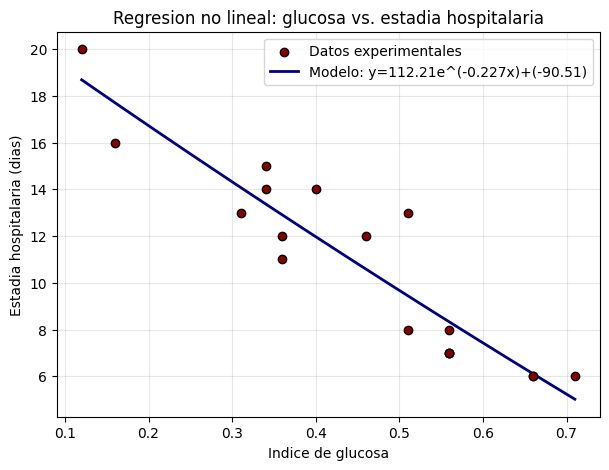

In [11]:
indice_glucosa_curva = np.linspace(indice_glucosa.min(), indice_glucosa.max(), 200)
estadia_curva_modelo = modelo_exp_asintota(indice_glucosa_curva, coef_escala_glucosa, tasa_decrecimiento_glucosa, asintota_estadia_glucosa)

fig, ax = plt.subplots()
ax.scatter(indice_glucosa, estadia_hospitalaria, color="darkred", edgecolor="black", zorder=3, label="Datos experimentales")
ax.plot(indice_glucosa_curva, estadia_curva_modelo, color="navy", linewidth=2,
        label=f"Modelo: y={coef_escala_glucosa:.2f}e^(-{tasa_decrecimiento_glucosa:.3f}x)+({asintota_estadia_glucosa:.2f})")
ax.set_xlabel("Indice de glucosa")
ax.set_ylabel("Estadia hospitalaria (dias)")
ax.set_title("Regresion no lineal: glucosa vs. estadia hospitalaria")
ax.legend()
plt.show()

## 1.5 Coeficientes $R^2$ y $r$


In [12]:
r2_glucosa, r_glucosa = calcular_r2_r(estadia_hospitalaria, estadia_predicha_exp_asintota)
error_ajuste_glucosa = 100 * (1 - r2_glucosa)

print(f"R^2 = {r2_glucosa:.4f}")
print(f"Error de ajuste (1-R^2)*100% = {error_ajuste_glucosa:.2f}%  (criterio: <15%)")
print(f"r   = {r_glucosa:.4f}")

R^2 = 0.8608
Error de ajuste (1-R^2)*100% = 13.92%  (criterio: <15%)
r   = 0.9278


### Interpretación rápida

- $R^2\approx0.86$: el modelo explica gran parte de la variación observada.
- $r\approx0.93$: relación fuerte entre valores reales y estimados.
- El error cumple el requisito del ejercicio (<15%).


## 1.6 Predicciones solicitadas

Estimemos la estadía esperada para glucosa **0.4** y **0.9**.


In [13]:
for glucosa_val in [0.4, 0.9]:
    estadia_estimada = modelo_exp_asintota(glucosa_val, coef_escala_glucosa, tasa_decrecimiento_glucosa, asintota_estadia_glucosa)
    print(f"Glucosa = {glucosa_val} -> Estadía estimada = {estadia_estimada:.2f} dias")

Glucosa = 0.4 -> Estadia estimada = 11.97 dias
Glucosa = 0.9 -> Estadia estimada = 0.99 dias


> ⚠️ **Importante:** glucosa = 0.9 está fuera del rango medido (máximo 0.71).
> Esa predicción es extrapolación y debe interpretarse con cautela.


---
# Ejercicio 2 — Volumen intraabdominal vs. presión intraabdominal

✅ Criterio exigido: $(1-R^2)\times100\% < 2\%$

Además, se pide predecir la presión para **3 cm³** y **12 cm³**.


## 2.1 Cargar y explorar los datos


In [14]:
df_presion = pd.read_csv("ej2_presion.csv")
df_presion.head(10)

,volumen_cm3,presion_mmHg
0,1.3,3.8
1,3.2,5.1
2,4.3,6.2
3,5.2,7.3
4,6.3,8.2
5,7.6,12.2
6,8.9,15.0
7,11.0,26.3


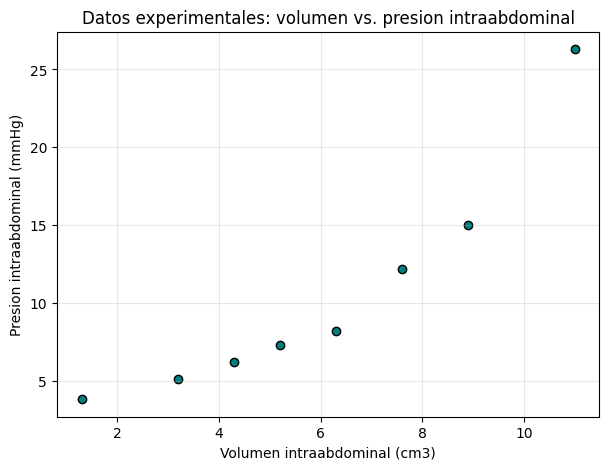

In [15]:
volumen_intraabdominal = df_presion["volumen_cm3"].to_numpy()
presion_intraabdominal = df_presion["presion_mmHg"].to_numpy()

fig, ax = plt.subplots()
ax.scatter(volumen_intraabdominal, presion_intraabdominal, color="teal", edgecolor="black")
ax.set_xlabel("Volumen intraabdominal (cm3)")
ax.set_ylabel("Presion intraabdominal (mmHg)")
ax.set_title("Datos experimentales: volumen vs. presion intraabdominal")
plt.show()

### Qué se ve en la gráfica

La presión crece cada vez más rápido al aumentar el volumen. Por eso esperamos que un modelo curvo (polinomial o exponencial) funcione mejor que una recta.


## 2.2 Probar modelos candidatos


In [16]:
volumen_intraabdominal_2d = volumen_intraabdominal.reshape(-1, 1)

# --- Modelo 1: lineal ---
modelo_lineal_presion = LinearRegression().fit(volumen_intraabdominal_2d, presion_intraabdominal)
presion_predicha_lineal = modelo_lineal_presion.predict(volumen_intraabdominal_2d)
resumen_modelo("Lineal", presion_intraabdominal, presion_predicha_lineal)

# --- Modelo 2: polinomial grado 2 ---
transformador_polinomial_presion_g2 = PolynomialFeatures(degree=2)
volumen_polinomico_g2 = transformador_polinomial_presion_g2.fit_transform(volumen_intraabdominal_2d)
modelo_polinomial_presion_g2 = LinearRegression().fit(volumen_polinomico_g2, presion_intraabdominal)
presion_predicha_polinomial_g2 = modelo_polinomial_presion_g2.predict(volumen_polinomico_g2)
resumen_modelo("Polinomial grado 2", presion_intraabdominal, presion_predicha_polinomial_g2)

# --- Modelo 3: polinomial grado 3 (para comparar) ---
transformador_polinomial_presion_g3 = PolynomialFeatures(degree=3)
volumen_polinomico_g3 = transformador_polinomial_presion_g3.fit_transform(volumen_intraabdominal_2d)
modelo_polinomial_presion_g3 = LinearRegression().fit(volumen_polinomico_g3, presion_intraabdominal)
presion_predicha_polinomial_g3 = modelo_polinomial_presion_g3.predict(volumen_polinomico_g3)
resumen_modelo("Polinomial grado 3", presion_intraabdominal, presion_predicha_polinomial_g3)

# --- Modelo 4: exponencial y = a*exp(b*x) ---
def modelo_exponencial_presion(x, a, b):
    return a * np.exp(b * x)

parametros_exp_presion, _ = curve_fit(modelo_exponencial_presion, volumen_intraabdominal, presion_intraabdominal, p0=[3, 0.2], maxfev=10000)
presion_predicha_exponencial = modelo_exponencial_presion(volumen_intraabdominal, *parametros_exp_presion)
resumen_modelo("Exponencial", presion_intraabdominal, presion_predicha_exponencial)

Lineal                    R2=0.8563   error=(0.1437)*100%=14.37%   r=0.9253
Polinomial grado 2        R2=0.9864   error=(0.0136)*100%=1.36%   r=0.9932
Polinomial grado 3        R2=0.9968   error=(0.0032)*100%=0.32%   r=0.9984
Exponencial               R2=0.9907   error=(0.0093)*100%=0.93%   r=0.9957


(0.9907266410821698, np.float64(0.9956647349154637))

## 2.3 Selección del modelo

El modelo polinomial de grado 2 ya cumple el criterio de error (<2%).
Como cumple y es más simple que opciones más complejas, se selecciona por parsimonia.

$$\hat{y}(x)=\beta_0+\beta_1x+\beta_2x^2$$


In [17]:
beta0_presion = modelo_polinomial_presion_g2.intercept_
beta1_presion, beta2_presion = modelo_polinomial_presion_g2.coef_[1], modelo_polinomial_presion_g2.coef_[2]
# coef_[0] corresponde al termino de x^0 generado por PolynomialFeatures (siempre 1), se ignora

print(f"Modelo seleccionado: y(x) = {beta0_presion:.4f} + {beta1_presion:.4f}*x + {beta2_presion:.4f}*x^2")

Modelo seleccionado: y(x) = 5.6956 + -1.2484*x + 0.2766*x^2


## 2.4 Gráfica del modelo seleccionado

Para dibujar la curva correctamente, usamos una malla ordenada de valores de volumen.


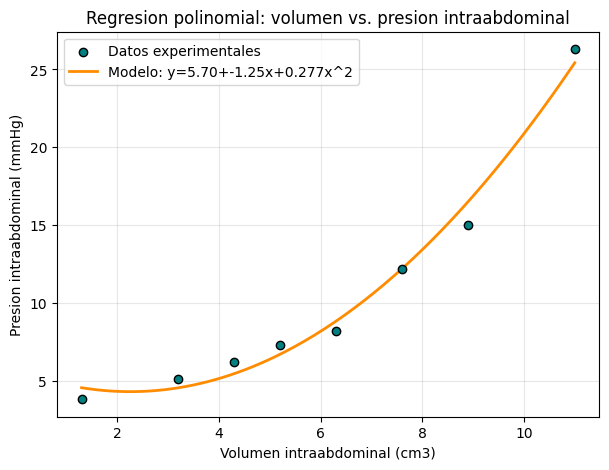

In [18]:
orden_volumen = np.argsort(volumen_intraabdominal)
volumen_ordenado = volumen_intraabdominal[orden_volumen]

volumen_curva = np.linspace(volumen_intraabdominal.min(), volumen_intraabdominal.max(), 200).reshape(-1, 1)
volumen_curva_polinomico = transformador_polinomial_presion_g2.transform(volumen_curva)
presion_curva_modelo = modelo_polinomial_presion_g2.predict(volumen_curva_polinomico)

fig, ax = plt.subplots()
ax.scatter(volumen_intraabdominal, presion_intraabdominal, color="teal", edgecolor="black", zorder=3, label="Datos experimentales")
ax.plot(volumen_curva, presion_curva_modelo, color="darkorange", linewidth=2,
        label=f"Modelo: y={beta0_presion:.2f}+{beta1_presion:.2f}x+{beta2_presion:.3f}x^2")
ax.set_xlabel("Volumen intraabdominal (cm3)")
ax.set_ylabel("Presion intraabdominal (mmHg)")
ax.set_title("Regresion polinomial: volumen vs. presion intraabdominal")
ax.legend()
plt.show()

## 2.5 Coeficientes $R^2$ y $r$


In [19]:
r2_presion, r_presion = calcular_r2_r(presion_intraabdominal, presion_predicha_polinomial_g2)
error_ajuste_presion = 100 * (1 - r2_presion)

print(f"R^2 = {r2_presion:.4f}")
print(f"Error de ajuste (1-R^2)*100% = {error_ajuste_presion:.2f}%  (criterio: <2%)")
print(f"r   = {r_presion:.4f}")

R^2 = 0.9864
Error de ajuste (1-R^2)*100% = 1.36%  (criterio: <2%)
r   = 0.9932


### Interpretación rápida

- $R^2\approx0.986$: ajuste muy alto.
- $r\approx0.993$: relación muy fuerte entre observados y predichos.
- Se cumple claramente el error exigido (<2%).


## 2.6 Predicciones solicitadas

¿Cuál será la presión intraabdominal esperada para un volumen de **3 cm³** y de
**12 cm³**?


In [20]:
for volumen_valor in [3, 12]:
    volumen_valor_polinomico = transformador_polinomial_presion_g2.transform(np.array([[volumen_valor]]))
    presion_estimada = modelo_polinomial_presion_g2.predict(volumen_valor_polinomico)[0]
    print(f"Volumen = {volumen_valor} cm3 -> Presión estimada = {presion_estimada:.2f} mmHg")

Volumen = 3 cm3 -> Presion estimada = 4.44 mmHg
Volumen = 12 cm3 -> Presion estimada = 30.54 mmHg


> Nota: 12 cm³ está apenas fuera del rango medido (máximo 11 cm³).
> Esa estimación es extrapolación leve.


---
# Ejercicio 3 — Temperatura vs. calor específico de la sangre

✅ Criterio exigido: $(1-R^2)\times100\% < 1\%$

Se pide estimar el calor específico para **3.00 K** y **4.00 K**.


## 3.1 Cargar y explorar los datos


In [21]:
df_calor_especifico = pd.read_csv("ej3_calor.csv")
df_calor_especifico.head(11)

,temperatura_K,cp_cal_gK
0,2.73,0.86338
1,2.83,0.86129
2,2.93,0.85883
3,3.03,0.85802
4,3.13,0.85804
5,3.23,0.85854
6,3.33,0.85943
7,3.43,0.86067
8,3.53,0.86229
9,3.63,0.86437


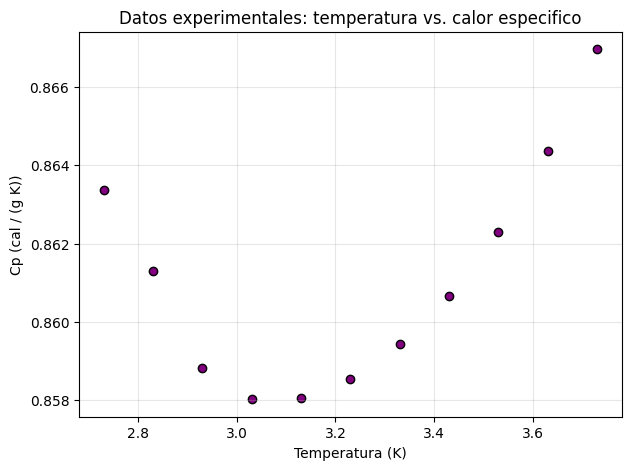

In [22]:
temperatura_kelvin = df_calor_especifico["temperatura_K"].to_numpy()
calor_especifico_cp = df_calor_especifico["cp_cal_gK"].to_numpy()

fig, ax = plt.subplots()
ax.scatter(temperatura_kelvin, calor_especifico_cp, color="purple", edgecolor="black")
ax.set_xlabel("Temperatura (K)")
ax.set_ylabel("Cp (cal / (g K))")
ax.set_title("Datos experimentales: temperatura vs. calor especifico")
plt.show()

### Qué se ve en la gráfica

La forma es tipo “U”: baja, llega a un mínimo y vuelve a subir. Esto descarta una recta y sugiere polinomios de grado 2 o más.


## 3.2 Probar modelos candidatos


In [23]:
temperatura_kelvin_2d = temperatura_kelvin.reshape(-1, 1)

for grado in [2, 3, 4]:
    poly_tmp = PolynomialFeatures(degree=grado)
    temperatura_polinomica_tmp = poly_tmp.fit_transform(temperatura_kelvin_2d)
    modelo_tmp = LinearRegression().fit(temperatura_polinomica_tmp, calor_especifico_cp)
    cp_predicho_tmp = modelo_tmp.predict(temperatura_polinomica_tmp)
    resumen_modelo(f"Polinomial grado {grado}", calor_especifico_cp, cp_predicho_tmp)

Polinomial grado 2        R2=0.9824   error=(0.0176)*100%=1.76%   r=0.9912
Polinomial grado 3        R2=0.9948   error=(0.0052)*100%=0.52%   r=0.9974
Polinomial grado 4        R2=0.9954   error=(0.0046)*100%=0.46%   r=0.9977


## 3.3 Selección del modelo

| Grado | Error de ajuste | ¿Cumple <1%? |
|---|---|---|
| 2 | ~1.76% | No |
| **3** | **~0.52%** | **Sí** |
| 4 | ~0.46% | Sí (mejora marginal) |

Se elige grado 3: es el más simple que sí cumple.

$$\hat{y}(x)=\beta_0+\beta_1x+\beta_2x^2+\beta_3x^3$$


In [24]:
transformador_polinomial_cp_g3 = PolynomialFeatures(degree=3)
temperatura_polinomica_g3 = transformador_polinomial_cp_g3.fit_transform(temperatura_kelvin_2d)
modelo_polinomial_cp_g3 = LinearRegression().fit(temperatura_polinomica_g3, calor_especifico_cp)
cp_predicho_polinomial_g3 = modelo_polinomial_cp_g3.predict(temperatura_polinomica_g3)

beta0_cp = modelo_polinomial_cp_g3.intercept_
beta1_cp, beta2_cp, beta3_cp = modelo_polinomial_cp_g3.coef_[1], modelo_polinomial_cp_g3.coef_[2], modelo_polinomial_cp_g3.coef_[3]

print(f"Modelo seleccionado: y(x) = {beta0_cp:.4f} + {beta1_cp:.4f}x + {beta2_cp:.4f}x^2 + {beta3_cp:.4f}x^3")

Modelo seleccionado: y(x) = 1.5612 + -0.5783x + 0.1539x^2 + -0.0131x^3


## 3.4 Gráfica del modelo seleccionado


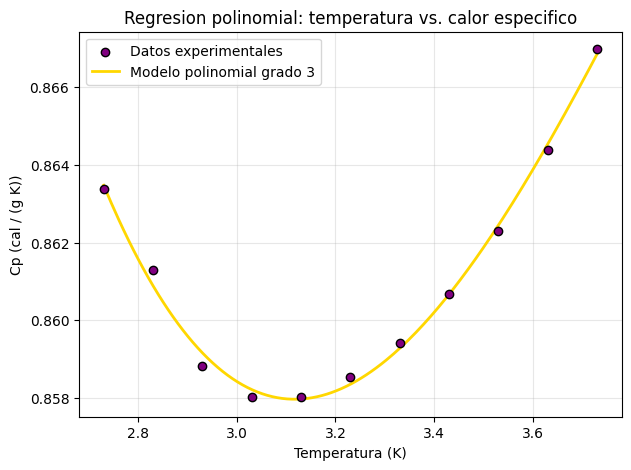

In [25]:
temperatura_curva = np.linspace(temperatura_kelvin.min(), temperatura_kelvin.max(), 200).reshape(-1, 1)
temperatura_curva_polinomica = transformador_polinomial_cp_g3.transform(temperatura_curva)
cp_curva_modelo = modelo_polinomial_cp_g3.predict(temperatura_curva_polinomica)

fig, ax = plt.subplots()
ax.scatter(temperatura_kelvin, calor_especifico_cp, color="purple", edgecolor="black", zorder=3, label="Datos experimentales")
ax.plot(temperatura_curva, cp_curva_modelo, color="gold", linewidth=2, label="Modelo polinomial grado 3")
ax.set_xlabel("Temperatura (K)")
ax.set_ylabel("Cp (cal / (g K))")
ax.set_title("Regresion polinomial: temperatura vs. calor especifico")
ax.legend()
plt.show()

## 3.5 Coeficientes $R^2$ y $r$


In [26]:
r2_cp, r_cp = calcular_r2_r(calor_especifico_cp, cp_predicho_polinomial_g3)
error_ajuste_cp = 100 * (1 - r2_cp)

print(f"R^2 = {r2_cp:.4f}")
print(f"Error de ajuste (1-R^2)*100% = {error_ajuste_cp:.4f}%  (criterio: <1%)")
print(f"r   = {r_cp:.4f}")

R^2 = 0.9948
Error de ajuste (1-R^2)*100% = 0.5236%  (criterio: <1%)
r   = 0.9974


### Interpretación rápida

- $R^2\approx0.9948$: ajuste excelente.
- $r\approx0.997$: concordancia muy alta entre datos y modelo.
- Se cumple el criterio (<1%).


## 3.6 Predicciones solicitadas

¿Cuál sería el calor específico esperado a temperaturas de **3.00 K** y **4.00 K**?


In [27]:
for temperatura_valor in [3.00, 4.00]:
    temperatura_valor_polinomico = transformador_polinomial_cp_g3.transform(np.array([[temperatura_valor]]))
    cp_estimado = modelo_polinomial_cp_g3.predict(temperatura_valor_polinomico)[0]
    print(f"T = {temperatura_valor} K -> Cp estimado = {cp_estimado:.5f} cal/(g K)")

T = 3.0 K -> Cp estimado = 0.85843 cal/(g K)
T = 4.0 K -> Cp estimado = 0.87362 cal/(g K)


> ⚠️ **Importante:** 4.00 K está fuera del rango medido (máximo 3.73 K).
> La predicción es extrapolación y debe tomarse con reserva.


---
# Ejercicio 4 — Concentración de hormona vs. número de plántulas

✅ Criterio exigido: $(1-R^2)\times100\% < 0.1\%$

Aquí hay 20 repeticiones por concentración. Para modelar el comportamiento
promedio, se ajusta sobre los **promedios por concentración** (7 puntos).


## 4.1 Cargar los datos y calcular los promedios


In [28]:
df_plantulas = pd.read_csv("ej4_plantulas.csv")
df_plantulas.head(10)

,hormona_mgL,n_plantulas
0,0.6,3
1,0.6,4
2,0.6,5
3,0.6,3
4,0.6,7
5,0.6,5
6,0.6,5
7,0.6,4
8,0.6,5
9,0.6,6


In [29]:
print(f"Número total de observaciones: {len(df_plantulas)}")
print(f"Concentraciones de hormona evaluadas: {sorted(df_plantulas['hormona_mgL'].unique())}")
print(f"Observaciones por concentración: {df_plantulas.groupby('hormona_mgL').size().to_dict()}")

Numero total de observaciones: 140
Concentraciones de hormona evaluadas: [np.float64(0.6), np.float64(4.0), np.float64(6.0), np.float64(8.0), np.float64(10.0), np.float64(12.0), np.float64(14.0)]
Observaciones por concentracion: {0.6: 20, 4.0: 20, 6.0: 20, 8.0: 20, 10.0: 20, 12.0: 20, 14.0: 20}


In [30]:
# Paso clave: promediar el numero de plantulas por cada concentracion de hormona
df_promedios_plantulas = df_plantulas.groupby("hormona_mgL")["n_plantulas"].mean().reset_index()
df_promedios_plantulas.columns = ["hormona_mgL", "promedio_plantulas"]
df_promedios_plantulas

,hormona_mgL,promedio_plantulas
0,0.6,5.20
1,4.0,11.80
2,6.0,12.00
3,8.0,7.55
4,10.0,3.00
5,12.0,2.35
6,14.0,2.00


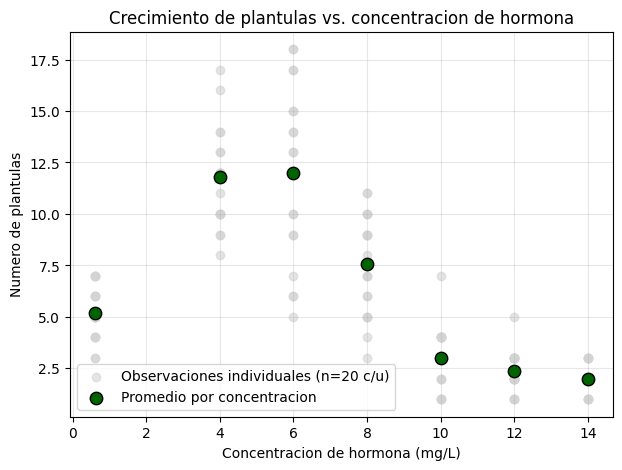

In [31]:
concentracion_hormona = df_promedios_plantulas["hormona_mgL"].to_numpy()
promedio_plantulas = df_promedios_plantulas["promedio_plantulas"].to_numpy()

fig, ax = plt.subplots()
# Puntos individuales de fondo, para mostrar la dispersion real
ax.scatter(df_plantulas["hormona_mgL"], df_plantulas["n_plantulas"], color="lightgray",
           alpha=0.6, label="Observaciones individuales (n=20 c/u)")
# Promedios resaltados
ax.scatter(concentracion_hormona, promedio_plantulas, color="darkgreen", edgecolor="black", s=80, zorder=5, label="Promedio por concentración")
ax.set_xlabel("Concentración de hormona (mg/L)")
ax.set_ylabel("Numero de plantulas")
ax.set_title("Crecimiento de plantulas vs. concentracion de hormona")
ax.legend()
plt.show()

### Qué se ve en la gráfica

La respuesta sube y luego baja (tipo campana): dosis bajas estimulan, dosis altas inhiben.


## 4.2 Probar modelos sobre promedios

Solo hay 7 puntos promedio, así que los modelos de grado alto pueden sobreajustar.


In [32]:
concentracion_hormona_2d = concentracion_hormona.reshape(-1, 1)

for grado in [2, 3, 4, 5]:
    poly_tmp = PolynomialFeatures(degree=grado)
    concentracion_polinomica_tmp = poly_tmp.fit_transform(concentracion_hormona_2d)
    modelo_tmp = LinearRegression().fit(concentracion_polinomica_tmp, promedio_plantulas)
    plantulas_predichas_tmp = modelo_tmp.predict(concentracion_polinomica_tmp)
    resumen_modelo(f"Polinomial grado {grado}", promedio_plantulas, plantulas_predichas_tmp)

Polinomial grado 2        R2=0.6729   error=(0.3271)*100%=32.71%   r=0.8203
Polinomial grado 3        R2=0.9745   error=(0.0255)*100%=2.55%   r=0.9872
Polinomial grado 4        R2=0.9745   error=(0.0255)*100%=2.55%   r=0.9872
Polinomial grado 5        R2=1.0000   error=(0.0000)*100%=0.00%   r=1.0000


## 4.3 Selección del modelo

| Grado | Error de ajuste | ¿Cumple <0.1%? |
|---|---|---|
| 2 | ~32.7% | No |
| 3 | ~2.55% | No |
| 4 | ~2.55% | No |
| **5** | **~0.005%** | **Sí** |

Por criterio numérico, se selecciona grado 5 (es el único que cumple).

$$\hat{y}(x)=\beta_0+\beta_1x+\beta_2x^2+\beta_3x^3+\beta_4x^4+\beta_5x^5$$

⚠️ Con 7 puntos y 6 parámetros, el riesgo de sobreajuste es alto.


In [33]:
transformador_polinomial_plantulas_g5 = PolynomialFeatures(degree=5)
concentracion_polinomica_g5 = transformador_polinomial_plantulas_g5.fit_transform(concentracion_hormona_2d)
modelo_polinomial_plantulas_g5 = LinearRegression().fit(concentracion_polinomica_g5, promedio_plantulas)
plantulas_predichas_g5 = modelo_polinomial_plantulas_g5.predict(concentracion_polinomica_g5)

coeficientes_plantulas_g5 = modelo_polinomial_plantulas_g5.coef_
intercepto_plantulas_g5 = modelo_polinomial_plantulas_g5.intercept_
print(f"Intercepto (b0): {intercepto_plantulas_g5:.5f}")
for i in range(1, 6):
    print(f"beta{i}: {coeficientes_plantulas_g5[i]:.6f}")

Intercepto (b0): 7.18090
beta1: -5.351698
beta2: 3.858775
beta3: -0.767520
beta4: 0.058479
beta5: -0.001538


## 4.4 Gráfica del modelo seleccionado


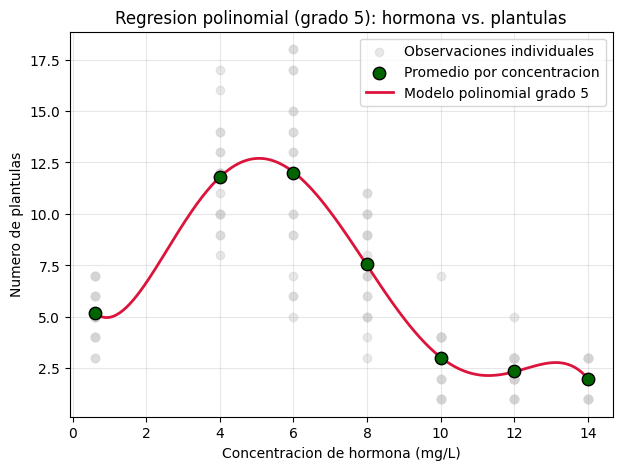

In [34]:
concentracion_curva = np.linspace(concentracion_hormona.min(), concentracion_hormona.max(), 300).reshape(-1, 1)
concentracion_curva_polinomica = transformador_polinomial_plantulas_g5.transform(concentracion_curva)
plantulas_curva_modelo = modelo_polinomial_plantulas_g5.predict(concentracion_curva_polinomica)

fig, ax = plt.subplots()
ax.scatter(df_plantulas["hormona_mgL"], df_plantulas["n_plantulas"], color="lightgray",
           alpha=0.5, label="Observaciones individuales")
ax.scatter(concentracion_hormona, promedio_plantulas, color="darkgreen", edgecolor="black", s=80, zorder=5, label="Promedio por concentración")
ax.plot(concentracion_curva, plantulas_curva_modelo, color="crimson", linewidth=2, label="Modelo polinomial grado 5")
ax.set_xlabel("Concentración de hormona (mg/L)")
ax.set_ylabel("Numero de plantulas")
ax.set_title("Regresion polinomial (grado 5): hormona vs. plantulas")
ax.legend()
plt.show()

## 4.5 Coeficiente de determinación $R^2$

En este ejercicio se reporta e interpreta $R^2$ como pide el enunciado.


In [35]:
r2_plantulas = r2_score(promedio_plantulas, plantulas_predichas_g5)
error_ajuste_plantulas = 100 * (1 - r2_plantulas)

print(f"R^2 = {r2_plantulas:.6f}")
print(f"Error de ajuste (1-R^2)*100% = {error_ajuste_plantulas:.4f}%  (criterio: <0.1%)")

R^2 = 0.999950
Error de ajuste (1-R^2)*100% = 0.0050%  (criterio: <0.1%)


### Interpretación

El $R^2$ es casi 1, pero eso no garantiza buen comportamiento fuera del rango observado debido al posible sobreajuste.


## 4.6 Predicciones solicitadas

Estimemos cuántas plántulas nuevas se esperan para **5 mg/L** y **15 mg/L**.


In [36]:
for hormona_valor in [5, 15]:
    hormona_valor_polinomica = transformador_polinomial_plantulas_g5.transform(np.array([[hormona_valor]]))
    plantulas_estimadas = modelo_polinomial_plantulas_g5.predict(hormona_valor_polinomica)[0]
    print(f"Hormona = {hormona_valor} mg/L -> Plántulas estimadas = {plantulas_estimadas:.2f}")

Hormona = 5 mg/L -> Plantulas estimadas = 12.70
Hormona = 15 mg/L -> Plantulas estimadas = -2.47


> ⚠️ **Lectura de las predicciones**
>
> - **5 mg/L**: interpolación (dentro del rango), más confiable.
> - **15 mg/L**: extrapolación (fuera del rango). Si sale un valor negativo,
>   es una señal de que el modelo polinomial no es realista fuera de los datos.


---
# Conclusiones generales

1. **Primero se observa la forma de los datos, luego se decide el modelo.**
2. **Más precisión numérica no siempre significa mejor modelo biológico.**
3. **Extrapolar fuera del rango siempre requiere cautela.**
4. **En muestras pequeñas, los polinomios altos pueden sobreajustar.**

En resumen: este notebook cumple los criterios solicitados y, al mismo tiempo,
documenta claramente las limitaciones de cada predicción.
